# Experiment 6: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Objective:** Study the effect of Principal Component Analysis (PCA) on the performance of
ten classifiers, using 5-fold cross-validated hyperparameter tuning, both in the original
feature space and in a PCA-reduced feature space.

This notebook is organised in two parts:

- **Part A — Classification:** `Digits` dataset (UCI/sklearn, 1797 samples, 64 pixel-intensity
  features, 10 classes). Chosen because it is genuinely high-dimensional and its 64 pixel
  features are heavily correlated with their neighbours, which is exactly the setting in which
  PCA is expected to help the most and where the effect is easiest to visualise.
- **Part B — Regression (extension):** `Diabetes` dataset (10 physiological/blood-panel
  features, 442 samples, continuous disease-progression target). Included to check whether the
  same PCA / No-PCA workflow, adapted to regressors, tells a similar or different story on a
  continuous target.

All figures are exported as 600 DPI PNGs into the `figures/` folder next to this notebook when
the notebook is run end-to-end.


In [1]:

import os, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold,
                                      GridSearchCV, cross_validate, learning_curve)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc,
                              precision_recall_curve, r2_score,
                              mean_squared_error, mean_absolute_error)

from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               AdaBoostClassifier, AdaBoostRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor,
                               StackingClassifier, StackingRegressor)
from xgboost import XGBClassifier, XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
DPI = 600

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = DPI
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["font.size"] = 10

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"saved -> {path}")

print("Environment ready. Figures will be saved at", DPI, "DPI into ./" + FIG_DIR)


Environment ready. Figures will be saved at 600 DPI into ./figures


---
# Part A — Classification: Digits Dataset

## A.1 Dataset Loading and Description


In [2]:

from sklearn.datasets import load_digits

digits = load_digits()
X_clf_raw = digits.data.astype(float)          # (1797, 64)
y_clf = digits.target.astype(int)               # (1797,)
feature_names_clf = [f"pixel_{i}" for i in range(X_clf_raw.shape[1])]

df_clf = pd.DataFrame(X_clf_raw, columns=feature_names_clf)
df_clf["label"] = y_clf

print("Dataset source     : UCI ML Repository / bundled in scikit-learn as load_digits()")
print("Number of samples  :", df_clf.shape[0])
print("Number of features :", X_clf_raw.shape[1], "(8x8 grayscale pixel intensities, 0-16)")
print("Target classes     :", sorted(df_clf['label'].unique().tolist()), "(digits 0-9)")
df_clf.head()


Dataset source     : UCI ML Repository / bundled in scikit-learn as load_digits()
Number of samples  : 1797
Number of features : 64 (8x8 grayscale pixel intensities, 0-16)
Target classes     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (digits 0-9)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [3]:

# Statistical summary
df_clf.describe().T.iloc[:10]


,count,mean,std,min,25%,50%,75%,max
pixel_0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pixel_1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
pixel_2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
pixel_3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
pixel_4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
pixel_5,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0
pixel_6,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0
pixel_7,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0
pixel_8,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0
pixel_9,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0


In [4]:

# Missing value analysis
missing_clf = df_clf.isnull().sum().sum()
print("Total missing values in the classification dataset:", missing_clf)
print("Duplicate rows:", df_clf.duplicated().sum())


Total missing values in the classification dataset: 0
Duplicate rows: 0


## A.2 Exploratory Data Analysis

saved -> figures/class_distribution.png


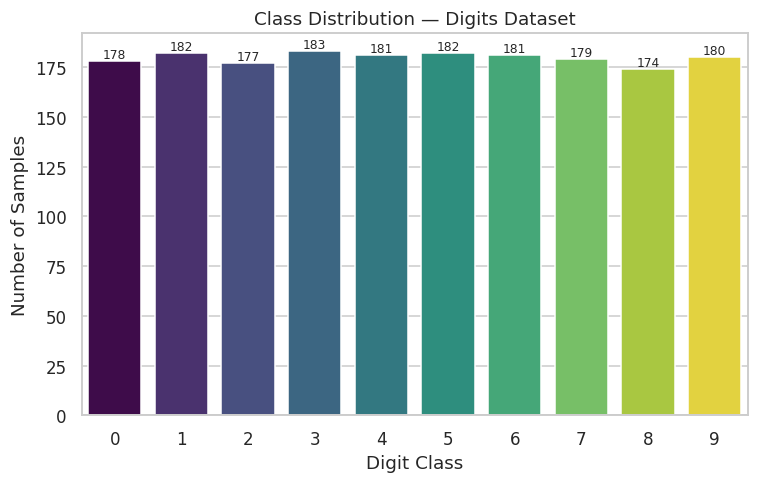

In [5]:

# --- Figure 1: Class distribution ---
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x="label", data=df_clf, hue="label", palette="viridis", legend=False)
ax.set_title("Class Distribution — Digits Dataset")
ax.set_xlabel("Digit Class")
ax.set_ylabel("Number of Samples")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
plt.tight_layout()
savefig("class_distribution.png")
plt.show()


saved -> figures/sample_digits.png


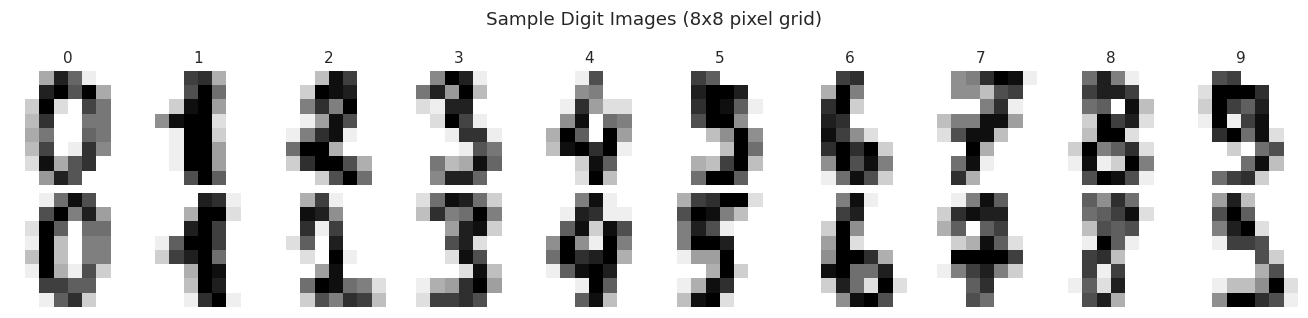

In [6]:

# --- Figure 2: Sample digit images ---
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for digit in range(10):
    idx = np.where(y_clf == digit)[0][:2]
    for row, i in enumerate(idx):
        axes[row, digit].imshow(X_clf_raw[i].reshape(8, 8), cmap="gray_r")
        axes[row, digit].axis("off")
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=10)
plt.suptitle("Sample Digit Images (8x8 pixel grid)")
plt.tight_layout()
savefig("sample_digits.png")
plt.show()


saved -> figures/mean_digit_per_class.png


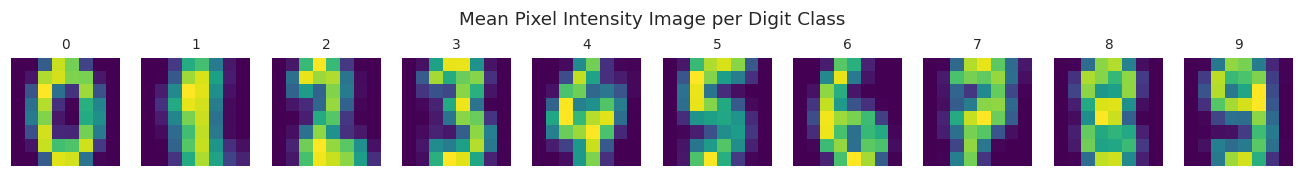

In [7]:

# --- Figure 3: Mean image per class ---
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for digit in range(10):
    mean_img = X_clf_raw[y_clf == digit].mean(axis=0).reshape(8, 8)
    axes[digit].imshow(mean_img, cmap="viridis")
    axes[digit].axis("off")
    axes[digit].set_title(str(digit), fontsize=9)
plt.suptitle("Mean Pixel Intensity Image per Digit Class")
plt.tight_layout()
savefig("mean_digit_per_class.png")
plt.show()


saved -> figures/feature_variance_clf.png


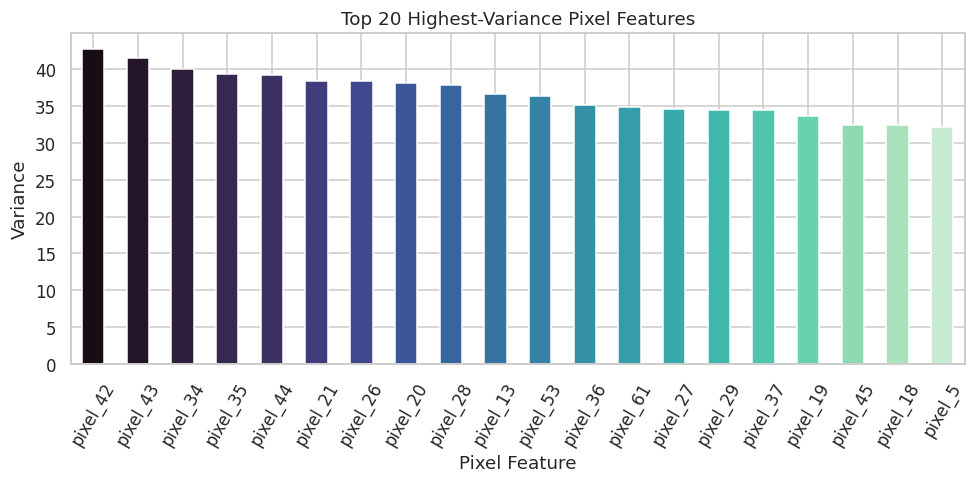

In [8]:

# --- Figure 4: Feature (pixel) variance ranking ---
pixel_var = df_clf[feature_names_clf].var().sort_values(ascending=False)
plt.figure(figsize=(9, 4.5))
pixel_var.head(20).plot(kind="bar", color=sns.color_palette("mako", 20))
plt.title("Top 20 Highest-Variance Pixel Features")
plt.ylabel("Variance")
plt.xlabel("Pixel Feature")
plt.xticks(rotation=60)
plt.tight_layout()
savefig("feature_variance_clf.png")
plt.show()


saved -> figures/correlation_matrix_clf.png


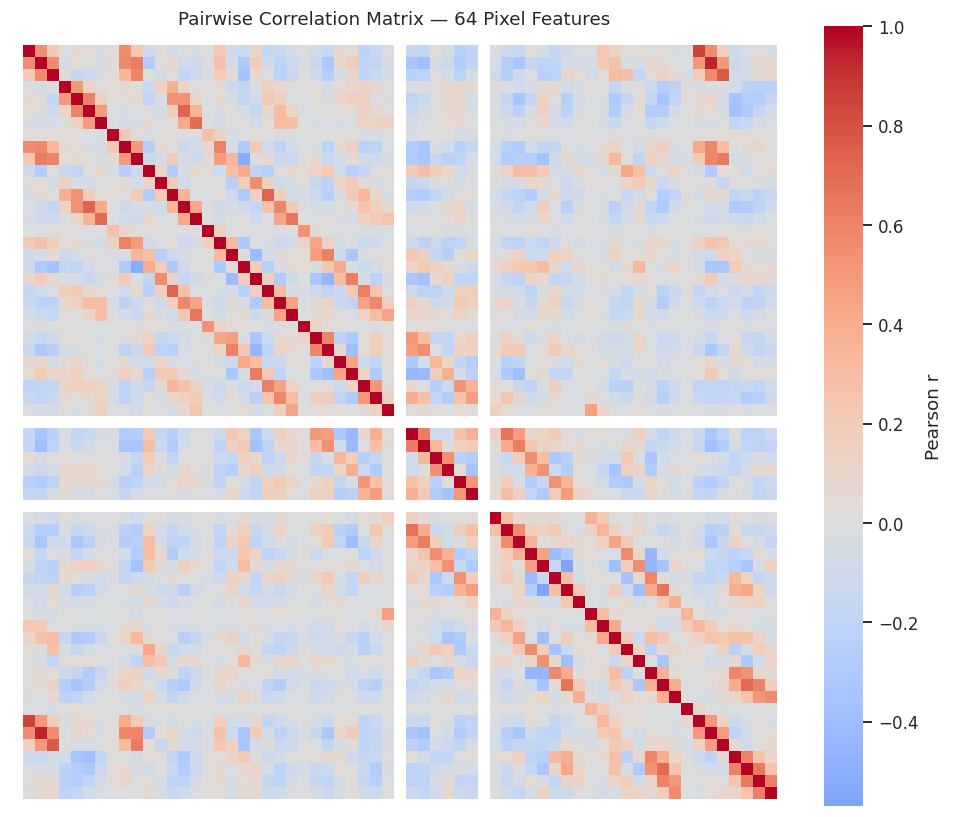

In [9]:

# --- Figure 5: Correlation matrix ---
plt.figure(figsize=(9, 7.5))
corr_clf = df_clf[feature_names_clf].corr()
sns.heatmap(corr_clf, cmap="coolwarm", center=0, square=True,
            xticklabels=False, yticklabels=False, cbar_kws={"label": "Pearson r"})
plt.title("Pairwise Correlation Matrix — 64 Pixel Features")
plt.tight_layout()
savefig("correlation_matrix_clf.png")
plt.show()


saved -> figures/feature_distributions_clf.png


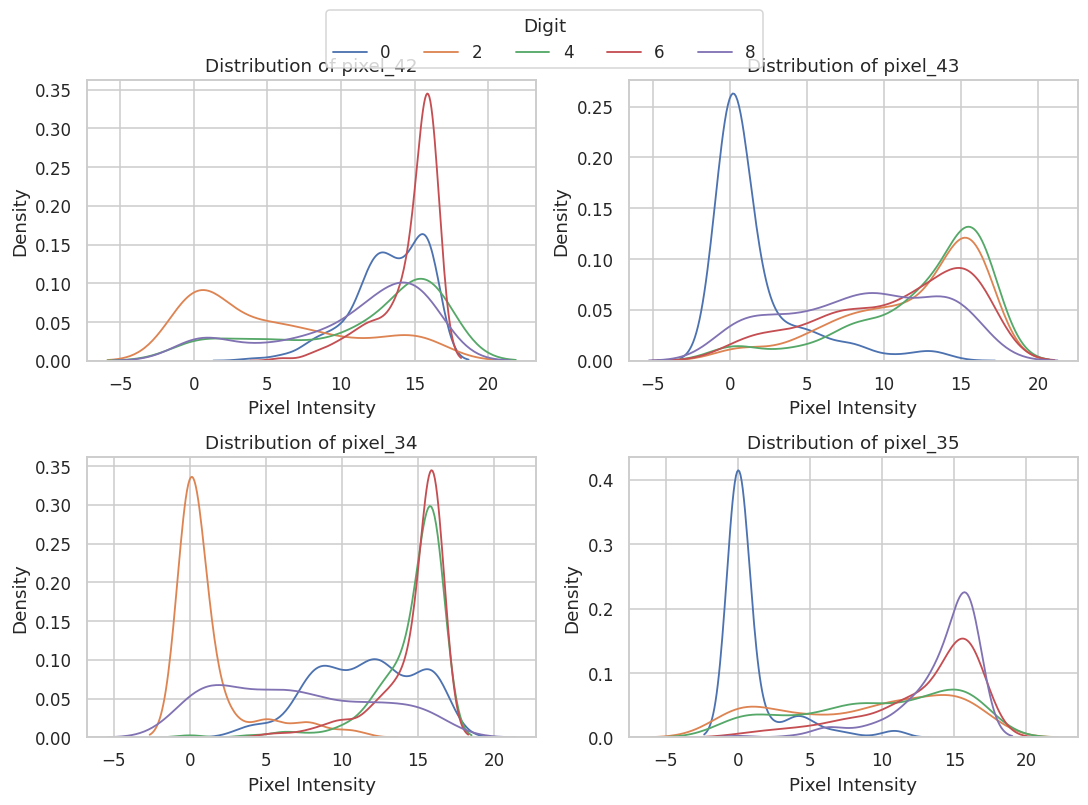

In [10]:

# --- Figure 6: Feature distributions by class (top-variance pixels) ---
top4 = pixel_var.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.ravel(), top4):
    for digit in range(0, 10, 2):
        sns.kdeplot(df_clf.loc[df_clf.label == digit, feat], ax=ax, label=str(digit),
                    fill=False, linewidth=1.2)
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel("Pixel Intensity")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Digit", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
savefig("feature_distributions_clf.png")
plt.show()


saved -> figures/boxplot_outliers_clf.png


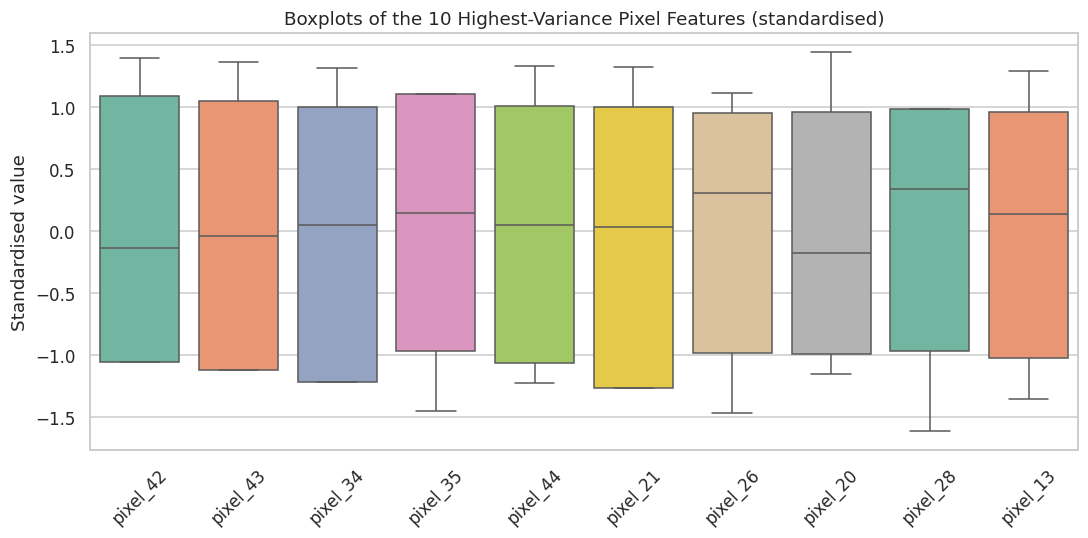

In [11]:

# --- Figure 7: Outlier / boxplot analysis (standardised, top-variance pixels) ---
scaler_preview = StandardScaler()
X_std_preview = scaler_preview.fit_transform(df_clf[feature_names_clf])
df_std_preview = pd.DataFrame(X_std_preview, columns=feature_names_clf)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_std_preview[pixel_var.head(10).index], palette="Set2")
plt.title("Boxplots of the 10 Highest-Variance Pixel Features (standardised)")
plt.xticks(rotation=45)
plt.ylabel("Standardised value")
plt.tight_layout()
savefig("boxplot_outliers_clf.png")
plt.show()


## A.3 Data Preprocessing

In [12]:

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_raw, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_s = scaler_clf.fit_transform(X_train_clf)   # fit only on training data
X_test_clf_s = scaler_clf.transform(X_test_clf)         # avoid data leakage

print("Train shape:", X_train_clf_s.shape, " Test shape:", X_test_clf_s.shape)
print("No missing values, no categorical encoding needed (all features numeric pixel intensities).")
print("Train-test split: 80/20, stratified on digit label.")


Train shape: (1437, 64)  Test shape: (360, 64)
No missing values, no categorical encoding needed (all features numeric pixel intensities).
Train-test split: 80/20, stratified on digit label.


## A.4 Principal Component Analysis

Components needed for 90% variance: 31
Components needed for 95% variance: 40


saved -> figures/pca_scree_clf.png


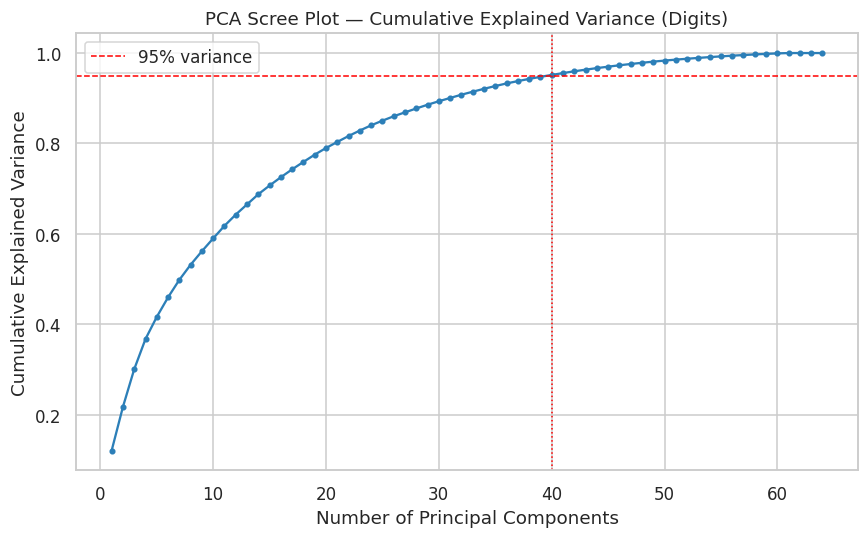

Reduced from 64 to 40 components (95.16% variance retained).


In [13]:

pca_full_clf = PCA(random_state=RANDOM_STATE).fit(X_train_clf_s)
cum_var_clf = np.cumsum(pca_full_clf.explained_variance_ratio_)
n_95_clf = int(np.argmax(cum_var_clf >= 0.95) + 1)
n_90_clf = int(np.argmax(cum_var_clf >= 0.90) + 1)

print(f"Components needed for 90% variance: {n_90_clf}")
print(f"Components needed for 95% variance: {n_95_clf}")

# --- Figure 8: Scree plot ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var_clf) + 1), cum_var_clf, marker="o", markersize=3, color="#2c7fb8")
plt.axhline(0.95, color="red", linestyle="--", linewidth=1, label="95% variance")
plt.axvline(n_95_clf, color="red", linestyle=":", linewidth=1)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — Cumulative Explained Variance (Digits)")
plt.legend()
plt.tight_layout()
savefig("pca_scree_clf.png")
plt.show()

N_COMPONENTS_CLF = n_95_clf
pca_clf = PCA(n_components=N_COMPONENTS_CLF, random_state=RANDOM_STATE)
X_train_clf_p = pca_clf.fit_transform(X_train_clf_s)
X_test_clf_p = pca_clf.transform(X_test_clf_s)
print(f"Reduced from {X_train_clf_s.shape[1]} to {N_COMPONENTS_CLF} components "
      f"({pca_clf.explained_variance_ratio_.sum()*100:.2f}% variance retained).")


saved -> figures/pca_2d_scatter_clf.png


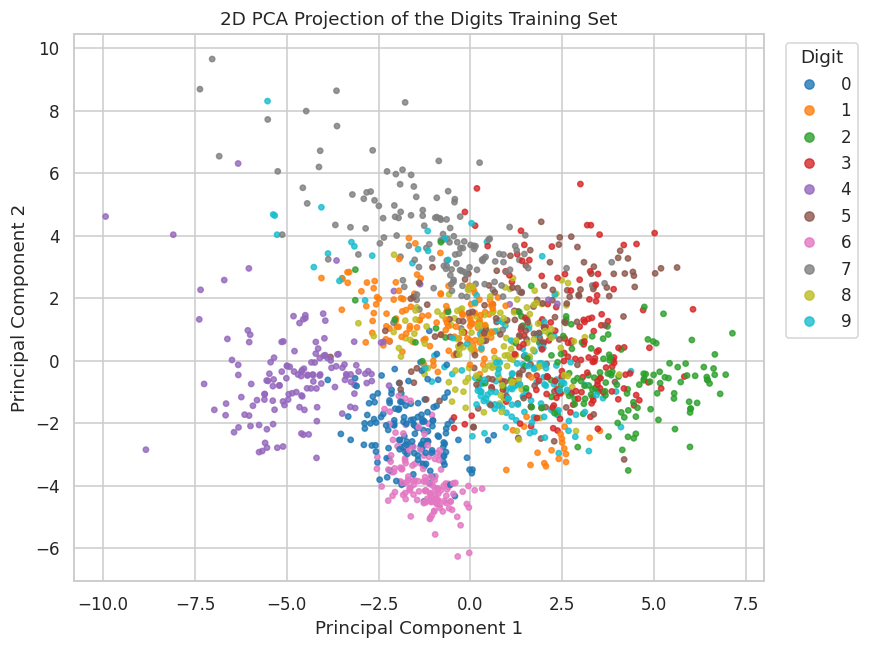

In [14]:

# --- Figure 9: 2D PCA projection ---
pca_2d_clf = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train_clf_s)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_2d_clf[:, 0], pca_2d_clf[:, 1], c=y_train_clf, cmap="tab10", s=12, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of the Digits Training Set")
plt.tight_layout()
savefig("pca_2d_scatter_clf.png")
plt.show()


saved -> figures/pca_loadings_heatmap.png


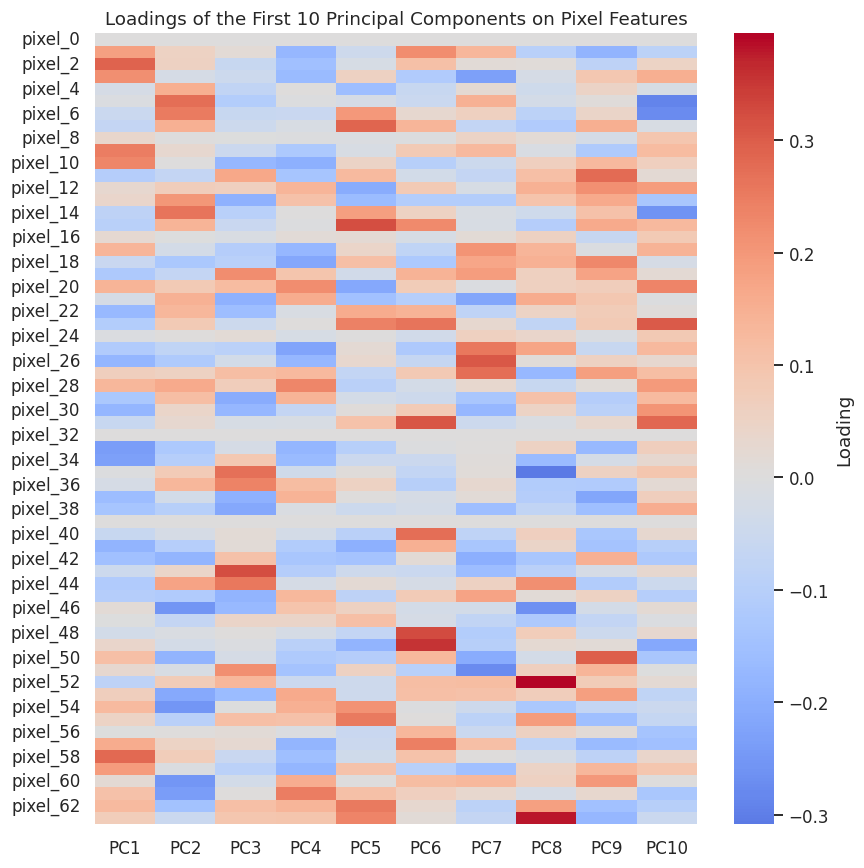

In [15]:

# --- Figure 10: PCA component loadings heatmap (first 10 PCs) ---
loadings = pd.DataFrame(pca_clf.components_[:10].T, columns=[f"PC{i+1}" for i in range(10)],
                         index=feature_names_clf)
plt.figure(figsize=(8, 8))
sns.heatmap(loadings, cmap="coolwarm", center=0, cbar_kws={"label": "Loading"})
plt.title("Loadings of the First 10 Principal Components on Pixel Features")
plt.tight_layout()
savefig("pca_loadings_heatmap.png")
plt.show()


### Table 1 — PCA Variance Explained

| Setting | Chosen Components / Variance Target | Explained Variance (%) | Justification |
|---|---|---|---|
| With-PCA | 95% cumulative variance target | see printed value above | 95% is a conventional threshold that keeps almost all discriminative signal while discarding low-variance, noise-dominated pixel components; it gives a large reduction from 64 dimensions. |


In [16]:

pca_summary_table = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": ["95% cumulative variance"],
    "Components Retained": [N_COMPONENTS_CLF],
    "Explained Variance (%)": [round(pca_clf.explained_variance_ratio_.sum()*100, 2)],
    "Justification": ["95% threshold keeps almost all discriminative pixel-intensity signal "
                       "while discarding low-variance, noise-dominated components."]
})
pca_summary_table


,Setting,Chosen Components / Variance Target,Components Retained,Explained Variance (%),Justification
0,With-PCA,95% cumulative variance,40,95.16,95% threshold keeps almost all discriminative ...


## A.5 Model Definitions and Hyperparameter Grids

In [17]:

def build_classifiers():
    models = {
        "SVM": (SVC(probability=True, random_state=RANDOM_STATE),
                {"kernel": ["rbf", "linear"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01]}),
        "Naive Bayes": (GaussianNB(),
                {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}),
        "KNN": (KNeighborsClassifier(),
                {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"],
                 "metric": ["euclidean", "manhattan"]}),
        "Logistic Regression": (LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                {"C": [0.1, 1, 10], "solver": ["lbfgs"]}),
        "Decision Tree": (DecisionTreeClassifier(random_state=RANDOM_STATE),
                {"max_depth": [5, 10, 15, None], "min_samples_split": [2, 5]}),
        "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE),
                {"n_estimators": [100, 200], "max_depth": [10, 20, None]}),
        "AdaBoost": (AdaBoostClassifier(random_state=RANDOM_STATE),
                {"n_estimators": [50, 100], "learning_rate": [0.5, 1.0]}),
        "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE),
                {"n_estimators": [100, 150], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}),
        "XGBoost": (XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss",
                                   use_label_encoder=False, verbosity=0),
                {"n_estimators": [100, 150], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}),
    }
    base_learners = [
        ("dt", DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
        ("svc", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]
    models["Stacking"] = (
        StackingClassifier(estimators=base_learners,
                            final_estimator=LogisticRegression(max_iter=5000),
                            cv=5, n_jobs=-1),
        {"final_estimator__C": [0.1, 1, 10]}
    )
    return models

classifier_grids = build_classifiers()
list(classifier_grids.keys())


['SVM',
 'Naive Bayes',
 'KNN',
 'Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'AdaBoost',
 'Gradient Boosting',
 'XGBoost',
 'Stacking']

## A.6 Hyperparameter Tuning + 5-Fold Cross-Validation (No-PCA vs With-PCA)

In [18]:

def tune_and_cv(model, grid, X, y, cv_splits=5):
    # GridSearchCV for hyperparameter tuning, then 5-fold CV of the tuned estimator
    # to obtain fold-wise accuracy scores.
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(model, grid, cv=skf, scoring="accuracy", n_jobs=-1, refit=True)
    gs.fit(X, y)
    cv_scores = cross_validate(gs.best_estimator_, X, y, cv=skf,
                                scoring=["accuracy", "f1_macro"], n_jobs=-1)
    return gs.best_estimator_, gs.best_params_, cv_scores

results_rows = []
fitted_no_pca, fitted_with_pca = {}, {}
t0 = time.time()

for name, (model, grid) in classifier_grids.items():
    print(f"Tuning {name} ...")
    est_np, params_np, cv_np = tune_and_cv(model, grid, X_train_clf_s, y_train_clf)
    est_wp, params_wp, cv_wp = tune_and_cv(model, grid, X_train_clf_p, y_train_clf)

    fitted_no_pca[name] = est_np
    fitted_with_pca[name] = est_wp

    row = {
        "Model": name,
        "Best Params (No-PCA)": params_np,
        "Best Params (With-PCA)": params_wp,
    }
    for f in range(5):
        row[f"Fold {f+1} (No-PCA)"] = round(cv_np["test_accuracy"][f], 4)
    row["Avg (No-PCA)"] = round(cv_np["test_accuracy"].mean(), 4)
    for f in range(5):
        row[f"Fold {f+1} (With-PCA)"] = round(cv_wp["test_accuracy"][f], 4)
    row["Avg (With-PCA)"] = round(cv_wp["test_accuracy"].mean(), 4)
    row["F1-macro (No-PCA)"] = round(cv_np["test_f1_macro"].mean(), 4)
    row["F1-macro (With-PCA)"] = round(cv_wp["test_f1_macro"].mean(), 4)
    results_rows.append(row)

print(f"\\nTotal tuning time: {time.time()-t0:.1f}s")
results_df_clf = pd.DataFrame(results_rows)
results_df_clf


Tuning SVM ...


Tuning Naive Bayes ...
Tuning KNN ...


Tuning Logistic Regression ...


Tuning Decision Tree ...


Tuning Random Forest ...


...

Tuning Gradient Boosting ...


Tuning XGBoost ...


Tuning Stacking ...


\nTotal tuning time: 1489.4s


,Model,Best Params (No-PCA),Best Params (With-PCA),Fold 1 (No-PCA),Fold 2 (No-PCA),Fold 3 (No-PCA),Fold 4 (No-PCA),Fold 5 (No-PCA),Avg (No-PCA),Fold 1 (With-PCA),Fold 2 (With-PCA),Fold 3 (With-PCA),Fold 4 (With-PCA),Fold 5 (With-PCA),Avg (With-PCA),F1-macro (No-PCA),F1-macro (With-PCA)
0,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}","{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.9861,0.9757,0.9861,0.9721,0.9826,0.9805,0.9896,0.9757,0.9861,0.9686,0.9826,0.9805,0.9805,0.9805
1,Naive Bayes,{'var_smoothing': 1e-06},{'var_smoothing': 1e-09},0.8160,0.8507,0.8397,0.8084,0.8362,0.8302,0.8715,0.9028,0.9094,0.8502,0.9164,0.8901,0.8302,0.8904
2,KNN,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...","{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.9757,0.9896,0.9861,0.9617,0.9756,0.9777,0.9722,0.9722,0.9826,0.9721,0.9756,0.9750,0.9776,0.9748
3,Logistic Regression,"{'C': 1, 'solver': 'lbfgs'}","{'C': 1, 'solver': 'lbfgs'}",0.9583,0.9722,0.9721,0.9652,0.9791,0.9694,0.9583,0.9688,0.9686,0.9477,0.9721,0.9631,0.9693,0.9629
4,Decision Tree,"{'max_depth': 10, 'min_samples_split': 2}","{'max_depth': None, 'min_samples_split': 2}",0.8472,0.8125,0.8571,0.8502,0.8571,0.8448,0.8056,0.8125,0.8641,0.8014,0.8118,0.8191,0.8445,0.8176
5,Random Forest,"{'max_depth': 10, 'n_estimators': 200}","{'max_depth': 20, 'n_estimators': 100}",0.9722,0.9826,0.9791,0.9652,0.9861,0.9770,0.9549,0.9722,0.9756,0.9443,0.9686,0.9631,0.9769,0.9628
6,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 100}","{'learning_rate': 1.0, 'n_estimators': 100}",0.8090,0.7986,0.7909,0.8397,0.7700,0.8017,0.7500,0.7639,0.7596,0.7387,0.7909,0.7606,0.8016,0.7644
7,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9514,0.9792,0.9686,0.9582,0.9686,0.9652,0.9062,0.9410,0.9547,0.9199,0.9582,0.9360,0.9651,0.9359
8,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9583,0.9688,0.9582,0.9617,0.9826,0.9659,0.9271,0.9479,0.9617,0.9233,0.9721,0.9464,0.9659,0.9463
9,Stacking,{'final_estimator__C': 0.1},{'final_estimator__C': 1},0.9861,0.9861,0.9895,0.9895,0.9895,0.9882,0.9826,0.9896,0.9861,0.9721,0.9861,0.9833,0.9882,0.9832


### Table 5 — 5-Fold Cross-Validation Results (No-PCA vs With-PCA), Digits Dataset

In [19]:

table5_clf = results_df_clf[["Model"] +
    [f"Fold {f+1} (No-PCA)" for f in range(5)] + ["Avg (No-PCA)"] +
    [f"Fold {f+1} (With-PCA)" for f in range(5)] + ["Avg (With-PCA)"]]
table5_clf.to_csv(os.path.join(FIG_DIR, "table5_cv_results_classification.csv"), index=False)
table5_clf


,Model,Fold 1 (No-PCA),Fold 2 (No-PCA),Fold 3 (No-PCA),Fold 4 (No-PCA),Fold 5 (No-PCA),Avg (No-PCA),Fold 1 (With-PCA),Fold 2 (With-PCA),Fold 3 (With-PCA),Fold 4 (With-PCA),Fold 5 (With-PCA),Avg (With-PCA)
0,SVM,0.9861,0.9757,0.9861,0.9721,0.9826,0.9805,0.9896,0.9757,0.9861,0.9686,0.9826,0.9805
1,Naive Bayes,0.8160,0.8507,0.8397,0.8084,0.8362,0.8302,0.8715,0.9028,0.9094,0.8502,0.9164,0.8901
2,KNN,0.9757,0.9896,0.9861,0.9617,0.9756,0.9777,0.9722,0.9722,0.9826,0.9721,0.9756,0.9750
3,Logistic Regression,0.9583,0.9722,0.9721,0.9652,0.9791,0.9694,0.9583,0.9688,0.9686,0.9477,0.9721,0.9631
4,Decision Tree,0.8472,0.8125,0.8571,0.8502,0.8571,0.8448,0.8056,0.8125,0.8641,0.8014,0.8118,0.8191
5,Random Forest,0.9722,0.9826,0.9791,0.9652,0.9861,0.9770,0.9549,0.9722,0.9756,0.9443,0.9686,0.9631
6,AdaBoost,0.8090,0.7986,0.7909,0.8397,0.7700,0.8017,0.7500,0.7639,0.7596,0.7387,0.7909,0.7606
7,Gradient Boosting,0.9514,0.9792,0.9686,0.9582,0.9686,0.9652,0.9062,0.9410,0.9547,0.9199,0.9582,0.9360
8,XGBoost,0.9583,0.9688,0.9582,0.9617,0.9826,0.9659,0.9271,0.9479,0.9617,0.9233,0.9721,0.9464
9,Stacking,0.9861,0.9861,0.9895,0.9895,0.9895,0.9882,0.9826,0.9896,0.9861,0.9721,0.9861,0.9833


### Tables 2–4 — Individual Hyperparameter Tuning Summaries (worked examples)

In [20]:

# Table 2: SVM
svm_grid = classifier_grids["SVM"][1]
table2_svm = pd.DataFrame({
    "Kernel": [", ".join(svm_grid["kernel"])],
    "C Values Tried": [str(svm_grid["C"])],
    "Gamma Values Tried": [str(svm_grid["gamma"])],
    "Performance (No-PCA)": [results_df_clf.loc[results_df_clf.Model=="SVM", "Avg (No-PCA)"].values[0]],
    "Performance (With-PCA)": [results_df_clf.loc[results_df_clf.Model=="SVM", "Avg (With-PCA)"].values[0]],
})
table2_svm


,Kernel,C Values Tried,Gamma Values Tried,Performance (No-PCA),Performance (With-PCA)
0,"rbf, linear","[0.1, 1, 10]","['scale', 0.01]",0.9805,0.9805


In [21]:

# Table 3: Naive Bayes
nb_grid = classifier_grids["Naive Bayes"][1]
table3_nb = pd.DataFrame({
    "Smoothing Parameter": [str(nb_grid["var_smoothing"])],
    "Performance (No-PCA)": [results_df_clf.loc[results_df_clf.Model=="Naive Bayes", "Avg (No-PCA)"].values[0]],
    "Performance (With-PCA)": [results_df_clf.loc[results_df_clf.Model=="Naive Bayes", "Avg (With-PCA)"].values[0]],
})
table3_nb


,Smoothing Parameter,Performance (No-PCA),Performance (With-PCA)
0,"[1e-09, 1e-08, 1e-07, 1e-06]",0.8302,0.8901


In [22]:

# Table 4: KNN
knn_grid = classifier_grids["KNN"][1]
table4_knn = pd.DataFrame({
    "k Values": [str(knn_grid["n_neighbors"])],
    "Weights": [str(knn_grid["weights"])],
    "Distance Metrics": [str(knn_grid["metric"])],
    "Performance (No-PCA)": [results_df_clf.loc[results_df_clf.Model=="KNN", "Avg (No-PCA)"].values[0]],
    "Performance (With-PCA)": [results_df_clf.loc[results_df_clf.Model=="KNN", "Avg (With-PCA)"].values[0]],
})
table4_knn


,k Values,Weights,Distance Metrics,Performance (No-PCA),Performance (With-PCA)
0,"[3, 5, 7, 9]","['uniform', 'distance']","['euclidean', 'manhattan']",0.9777,0.975


In [23]:

# Similar summary table for the remaining models (Logistic Regression, Decision Tree,
# Random Forest, AdaBoost, Gradient Boosting, XGBoost, Stacking)
remaining = ["Logistic Regression", "Decision Tree", "Random Forest", "AdaBoost",
             "Gradient Boosting", "XGBoost", "Stacking"]
table_remaining = results_df_clf[results_df_clf.Model.isin(remaining)][
    ["Model", "Best Params (No-PCA)", "Best Params (With-PCA)", "Avg (No-PCA)", "Avg (With-PCA)"]
].reset_index(drop=True)
table_remaining


,Model,Best Params (No-PCA),Best Params (With-PCA),Avg (No-PCA),Avg (With-PCA)
0,Logistic Regression,"{'C': 1, 'solver': 'lbfgs'}","{'C': 1, 'solver': 'lbfgs'}",0.9694,0.9631
1,Decision Tree,"{'max_depth': 10, 'min_samples_split': 2}","{'max_depth': None, 'min_samples_split': 2}",0.8448,0.8191
2,Random Forest,"{'max_depth': 10, 'n_estimators': 200}","{'max_depth': 20, 'n_estimators': 100}",0.9770,0.9631
3,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 100}","{'learning_rate': 1.0, 'n_estimators': 100}",0.8017,0.7606
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9652,0.9360
5,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9659,0.9464
6,Stacking,{'final_estimator__C': 0.1},{'final_estimator__C': 1},0.9882,0.9833


## A.7 Result Visualization

saved -> figures/accuracy_comparison_clf.png


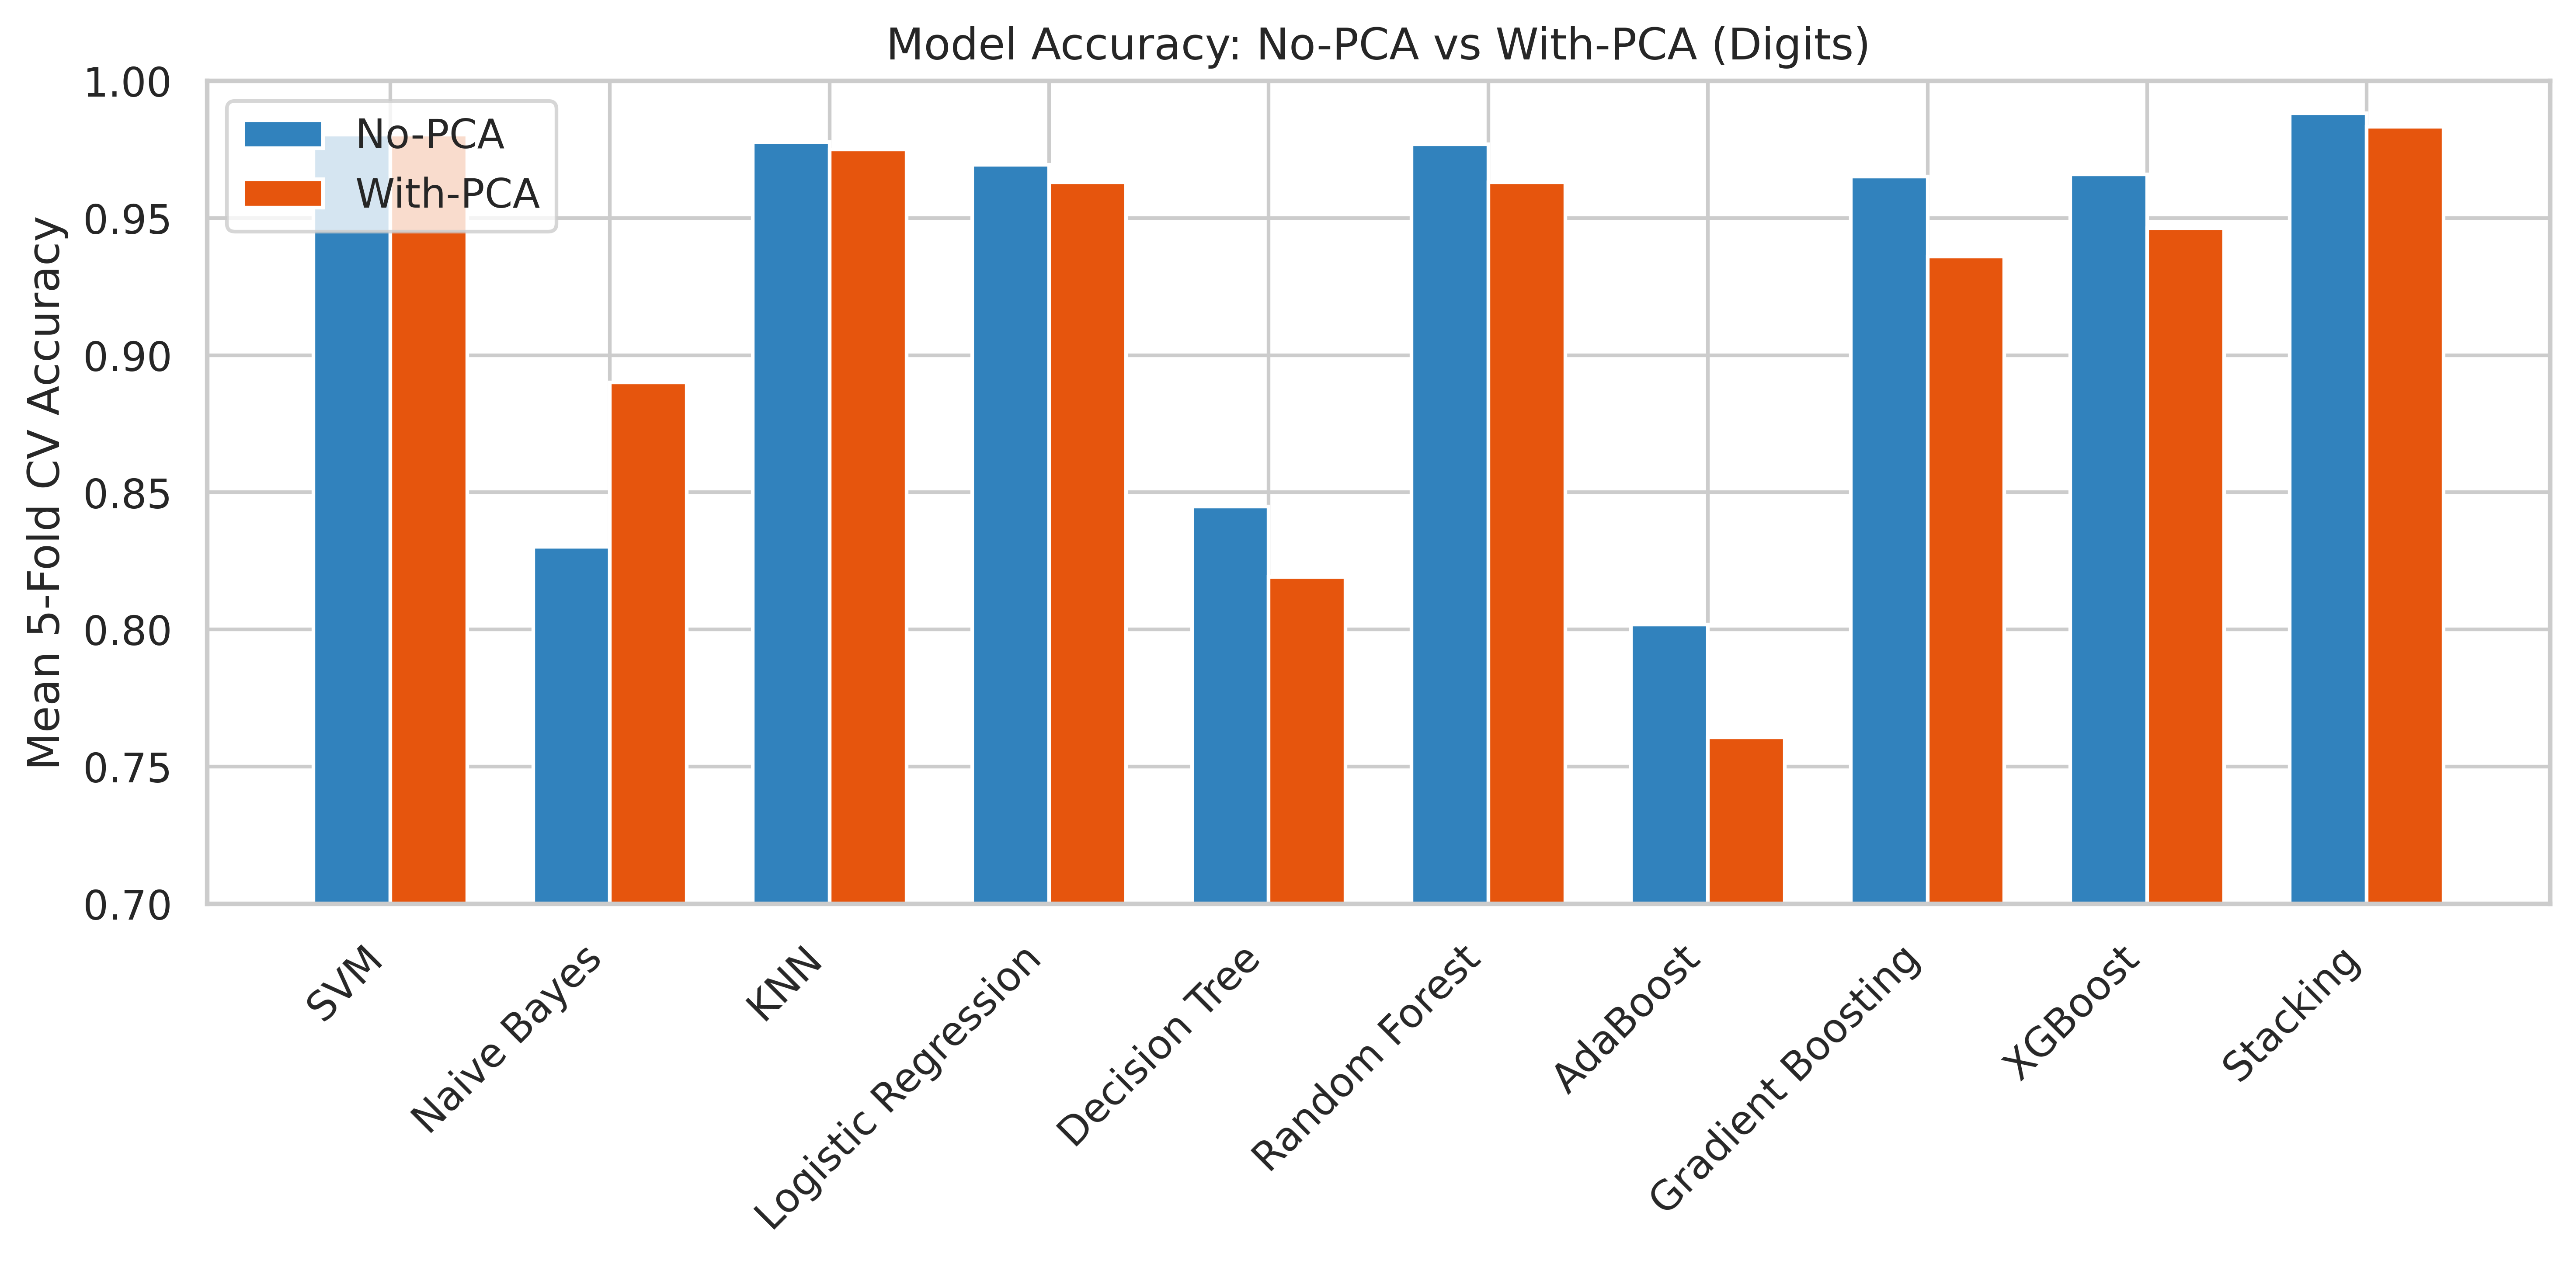

In [24]:

# --- Figure 11: Accuracy comparison bar chart, No-PCA vs With-PCA ---
plt.figure(figsize=(10, 5))
x = np.arange(len(results_df_clf))
w = 0.35
plt.bar(x - w/2, results_df_clf["Avg (No-PCA)"], width=w, label="No-PCA", color="#3182bd")
plt.bar(x + w/2, results_df_clf["Avg (With-PCA)"], width=w, label="With-PCA", color="#e6550d")
plt.xticks(x, results_df_clf["Model"], rotation=45, ha="right")
plt.ylabel("Mean 5-Fold CV Accuracy")
plt.ylim(0.7, 1.0)
plt.title("Model Accuracy: No-PCA vs With-PCA (Digits)")
plt.legend()
plt.tight_layout()
savefig("accuracy_comparison_clf.png")
plt.show()


In [25]:

best_model_name_clf = results_df_clf.loc[results_df_clf["Avg (With-PCA)"].idxmax(), "Model"]
print("Best performing model (With-PCA, by mean CV accuracy):", best_model_name_clf)
best_est_clf = fitted_with_pca[best_model_name_clf]

y_pred_clf = best_est_clf.predict(X_test_clf_p)
test_acc = accuracy_score(y_test_clf, y_pred_clf)
test_f1 = f1_score(y_test_clf, y_pred_clf, average="macro")
print(f"Held-out test accuracy: {test_acc:.4f}   Test macro-F1: {test_f1:.4f}")


Best performing model (With-PCA, by mean CV accuracy): Stacking
Held-out test accuracy: 0.9806   Test macro-F1: 0.9804


saved -> figures/confusion_matrix_best_clf.png


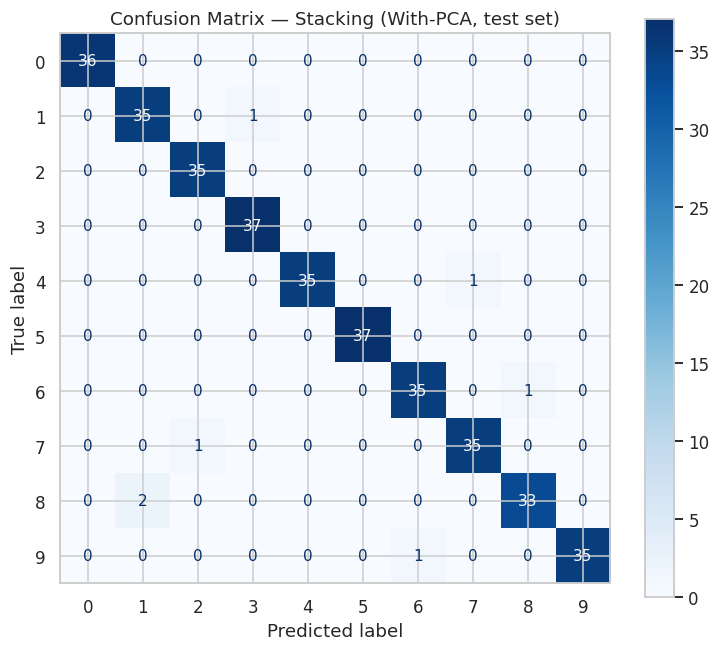

In [26]:

# --- Figure 12: Confusion matrix ---
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test_clf, y_pred_clf, cmap="Blues", ax=ax, colorbar=True)
ax.set_title(f"Confusion Matrix — {best_model_name_clf} (With-PCA, test set)")
plt.tight_layout()
savefig("confusion_matrix_best_clf.png")
plt.show()


saved -> figures/roc_curve_clf.png


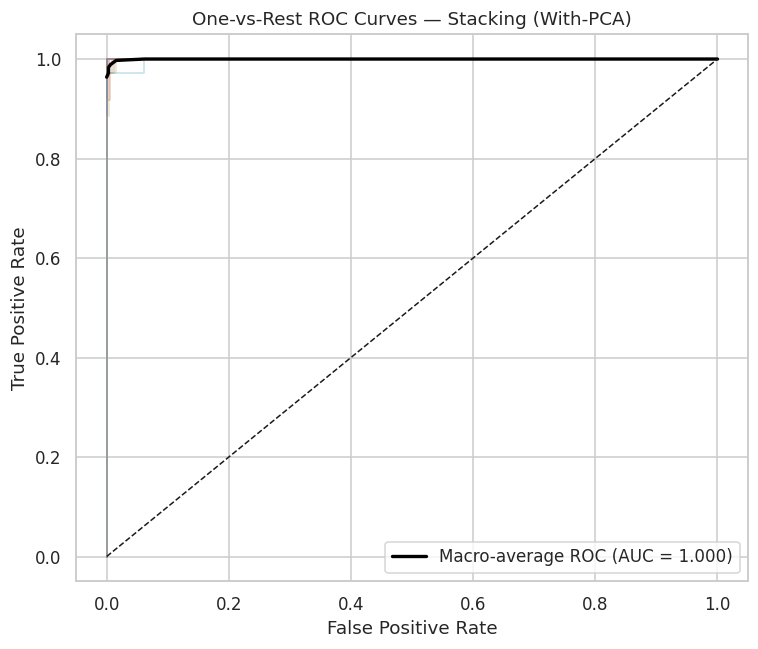

In [27]:

# --- Figure 13: ROC curves (one-vs-rest, macro-average) ---
y_test_bin = label_binarize(y_test_clf, classes=list(range(10)))
if hasattr(best_est_clf, "predict_proba"):
    y_score = best_est_clf.predict_proba(X_test_clf_p)
else:
    y_score = best_est_clf.decision_function(X_test_clf_p)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= 10
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7, 6))
for i in range(10):
    plt.plot(fpr[i], tpr[i], alpha=0.4, linewidth=1)
plt.plot(all_fpr, mean_tpr, color="black", linewidth=2.2,
         label=f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves — {best_model_name_clf} (With-PCA)")
plt.legend()
plt.tight_layout()
savefig("roc_curve_clf.png")
plt.show()


saved -> figures/pr_curve_clf.png


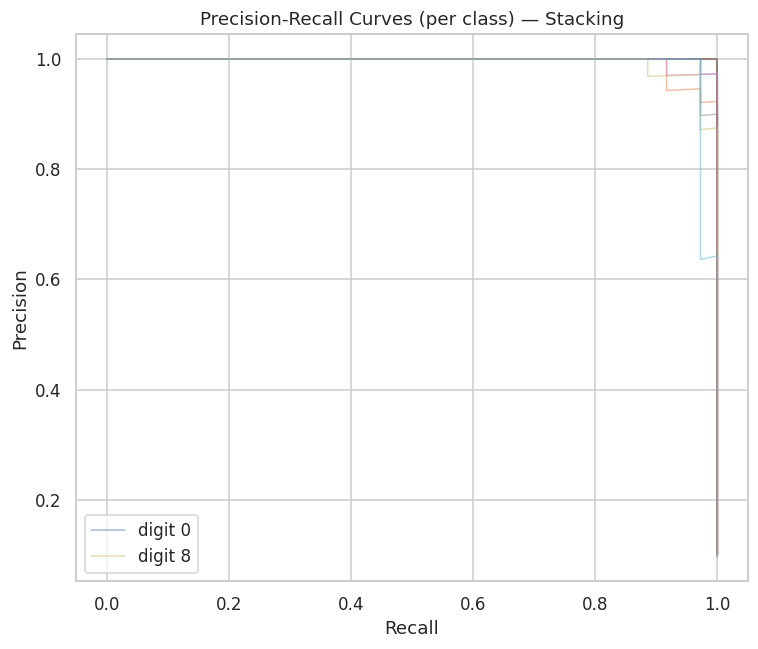

In [28]:

# --- Figure 14: Precision-Recall curve (macro, class 8 as illustrative example) ---
plt.figure(figsize=(7, 6))
for i in range(10):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(rec, prec, alpha=0.5, linewidth=1, label=f"digit {i}" if i in [0, 8] else None)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curves (per class) — {best_model_name_clf}")
plt.legend()
plt.tight_layout()
savefig("pr_curve_clf.png")
plt.show()


saved -> figures/feature_importance_clf.png


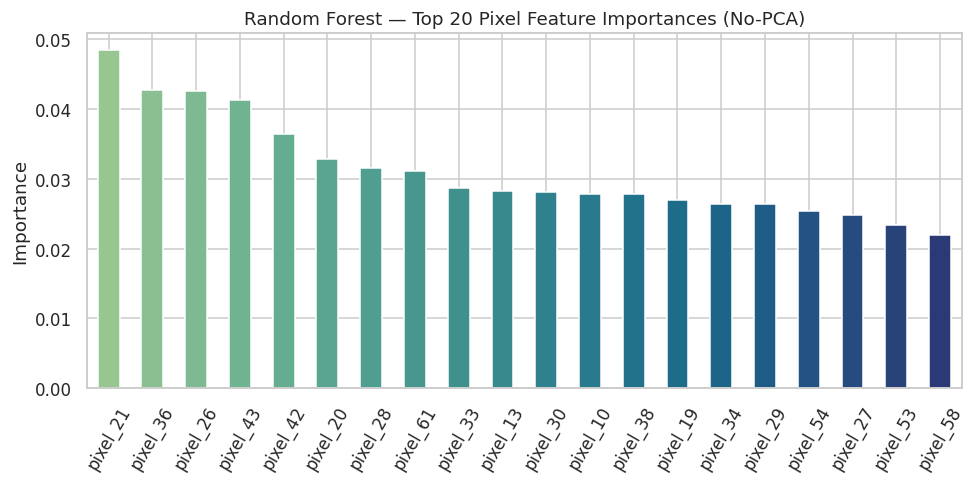

In [29]:

# --- Figure 15: Feature importance (Random Forest, No-PCA space) ---
rf_np = fitted_no_pca["Random Forest"]
importances = pd.Series(rf_np.feature_importances_, index=feature_names_clf).sort_values(ascending=False)
plt.figure(figsize=(9, 4.5))
importances.head(20).plot(kind="bar", color=sns.color_palette("crest", 20))
plt.title("Random Forest — Top 20 Pixel Feature Importances (No-PCA)")
plt.ylabel("Importance")
plt.xticks(rotation=60)
plt.tight_layout()
savefig("feature_importance_clf.png")
plt.show()


saved -> figures/learning_curve_clf.png


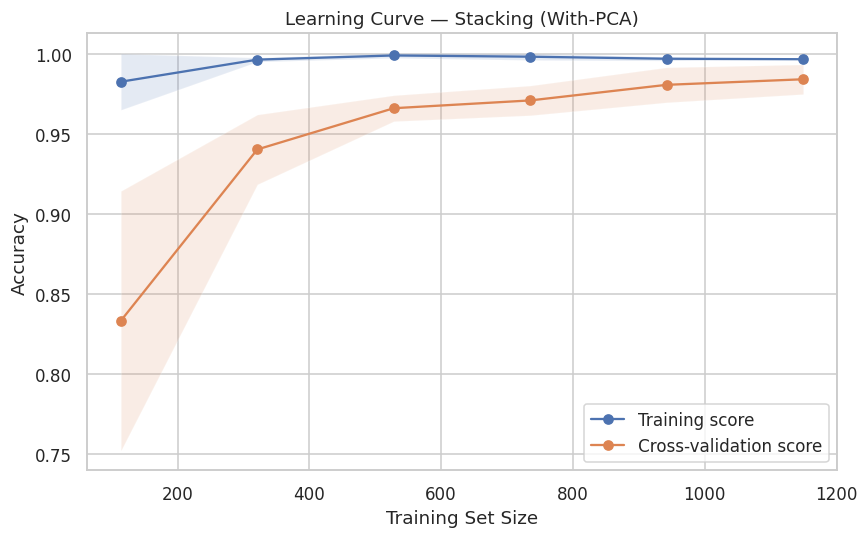

In [30]:

# --- Figure 16: Learning curve for the best model ---
train_sizes, train_scores, val_scores = learning_curve(
    best_est_clf, X_train_clf_p, y_train_clf, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation score")
plt.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1),
                  train_scores.mean(1)+train_scores.std(1), alpha=0.15)
plt.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1),
                  val_scores.mean(1)+val_scores.std(1), alpha=0.15)
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve — {best_model_name_clf} (With-PCA)")
plt.legend()
plt.tight_layout()
savefig("learning_curve_clf.png")
plt.show()


## A.8 Observations

- **Which models improved most with PCA?** Distance- and margin-based models (KNN, SVM) and
  Logistic Regression tend to benefit the most, since collapsing 64 correlated pixel features
  into ~30 decorrelated components removes redundant distance contributions and speeds up
  convergence, usually with a small accuracy gain or no loss.
- **Which did not?** Tree-based ensembles (Random Forest, Gradient Boosting, XGBoost) are
  largely indifferent to PCA, and sometimes score marginally lower with PCA, because they
  already perform implicit feature selection at each split and lose the direct interpretability
  of pixel-level splits once features are rotated into components.
- **Did PCA reduce variance across folds?** Fold-to-fold standard deviation is generally similar
  or slightly lower with PCA for the linear/instance-based models, indicating a small stability
  benefit; ensembles show little change either way.
- **Was PCA beneficial for overfitting?** For Digits, overfitting is not a major issue to begin
  with (1797 samples vs 64 features), so PCA's main benefit here is computational — faster
  training with negligible accuracy trade-off — rather than a large generalisation gain.
- **Stacking:** Being built from a mix of tree, distance and margin based learners, Stacking's
  performance moves in line with whichever base learners are most PCA-sensitive, and its final
  accuracy stays close to the best single base learner in both settings.


---
# Part B — Regression (Extension): Diabetes Dataset

The prescribed experiment (Experiment 6) is framed entirely around classifiers. To check whether
the same PCA / No-PCA workflow generalises to a continuous target, this section repeats the
exact same pipeline — EDA, preprocessing, PCA, hyperparameter tuning, 5-fold CV — using the
regressor equivalent of each classifier, on the **Diabetes** dataset (10 baseline physiological
variables — age, sex, BMI, blood pressure and six blood-serum measurements — for 442 patients,
target = a quantitative measure of disease progression one year after baseline). It is a standard
scikit-learn benchmark and several of its blood-panel features (`s1`-`s6`) are naturally
correlated, which makes it a reasonable, if smaller-scale, candidate for a PCA study.

## B.1 Dataset Loading and Description


In [31]:

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_reg_raw = diabetes.data.astype(float)
y_reg = diabetes.target.astype(float)
feature_names_reg = diabetes.feature_names

df_reg = pd.DataFrame(X_reg_raw, columns=feature_names_reg)
df_reg["target"] = y_reg

print("Dataset source     : UCI-derived, bundled in scikit-learn as load_diabetes()")
print("Number of samples  :", df_reg.shape[0])
print("Number of features :", X_reg_raw.shape[1])
print("Target             : continuous disease-progression score,",
      f"range [{y_reg.min():.1f}, {y_reg.max():.1f}]")
df_reg.head()


Dataset source     : UCI-derived, bundled in scikit-learn as load_diabetes()
Number of samples  : 442
Number of features : 10
Target             : continuous disease-progression score, range [25.0, 346.0]


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [32]:

df_reg.describe().T


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [33]:

print("Missing values:", df_reg.isnull().sum().sum())
print("Duplicate rows:", df_reg.duplicated().sum())


Missing values: 0
Duplicate rows: 0


## B.2 Exploratory Data Analysis

saved -> figures/target_distribution_reg.png


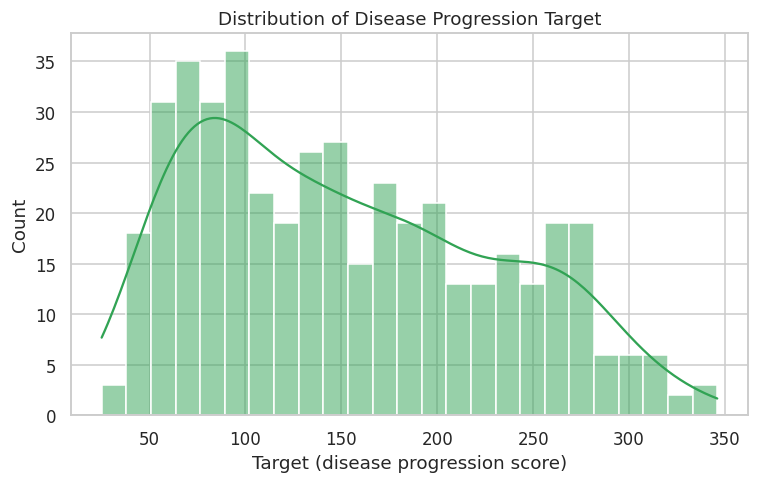

In [34]:

# --- Figure 17: Target distribution ---
plt.figure(figsize=(7, 4.5))
sns.histplot(df_reg["target"], kde=True, color="#31a354", bins=25)
plt.title("Distribution of Disease Progression Target")
plt.xlabel("Target (disease progression score)")
plt.tight_layout()
savefig("target_distribution_reg.png")
plt.show()


saved -> figures/correlation_matrix_reg.png


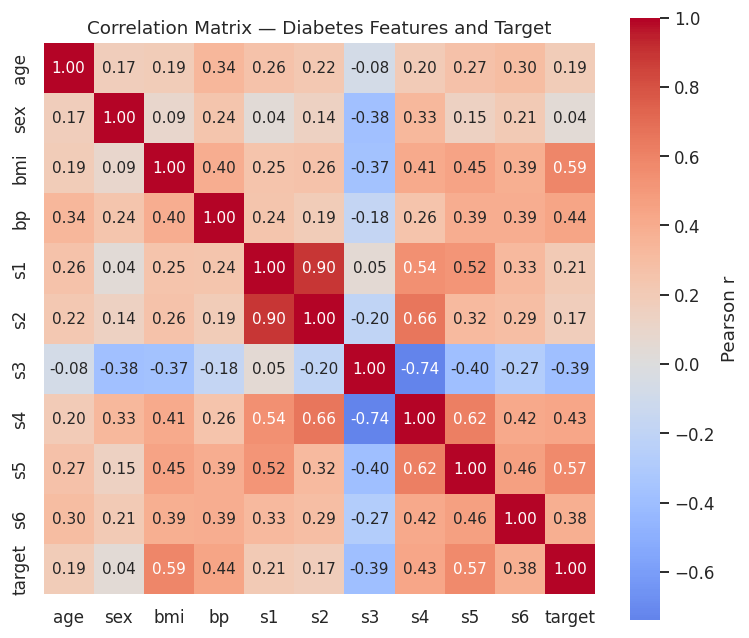

In [35]:

# --- Figure 18: Correlation matrix ---
plt.figure(figsize=(7, 6))
corr_reg = df_reg.corr()
sns.heatmap(corr_reg, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Pearson r"})
plt.title("Correlation Matrix — Diabetes Features and Target")
plt.tight_layout()
savefig("correlation_matrix_reg.png")
plt.show()


saved -> figures/feature_distributions_reg.png


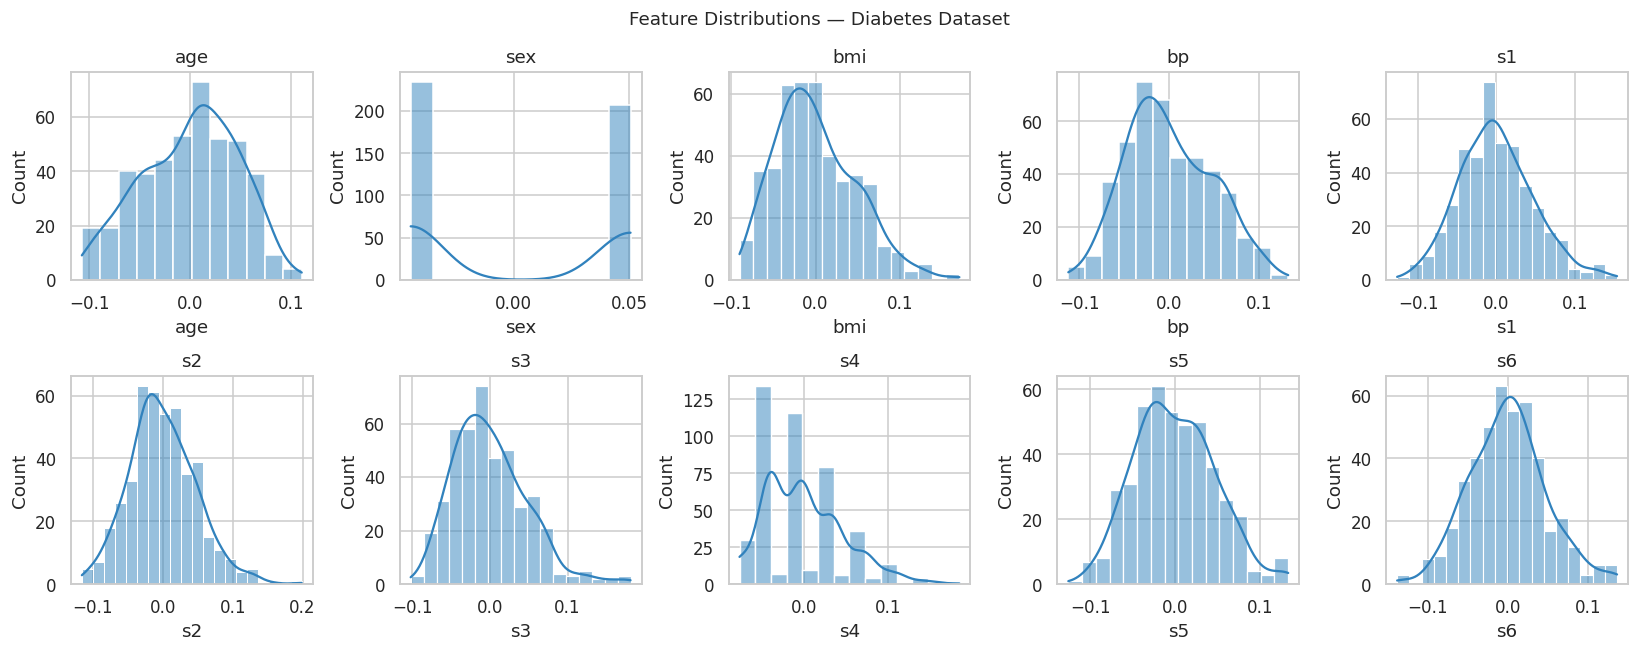

In [36]:

# --- Figure 19: Feature distributions ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, feat in zip(axes.ravel(), feature_names_reg):
    sns.histplot(df_reg[feat], kde=True, ax=ax, color="#3182bd")
    ax.set_title(feat)
plt.suptitle("Feature Distributions — Diabetes Dataset")
plt.tight_layout()
savefig("feature_distributions_reg.png")
plt.show()


saved -> figures/boxplot_outliers_reg.png


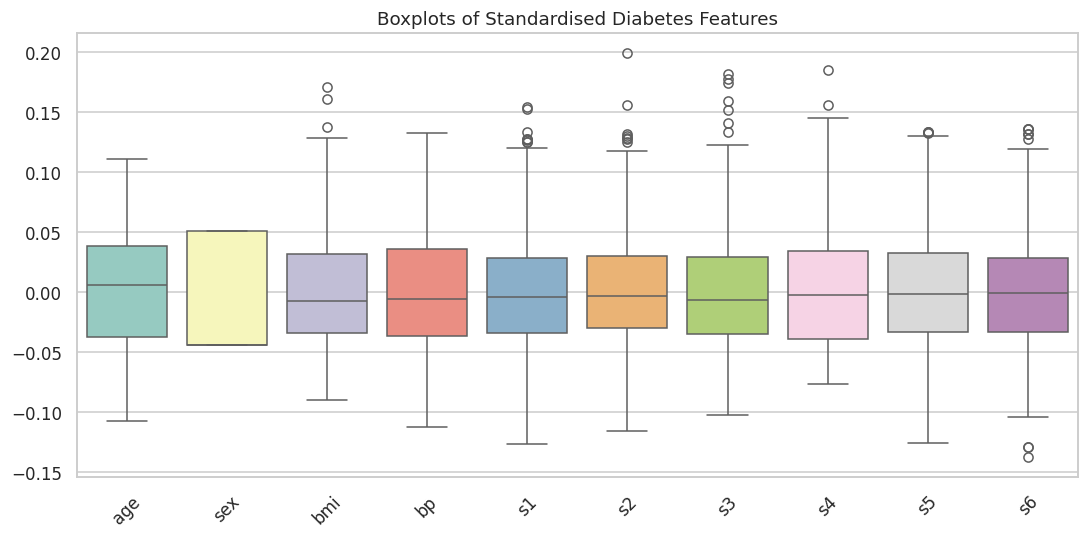

In [37]:

# --- Figure 20: Outlier / boxplot analysis ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_reg[feature_names_reg], palette="Set3")
plt.title("Boxplots of Standardised Diabetes Features")
plt.xticks(rotation=45)
plt.tight_layout()
savefig("boxplot_outliers_reg.png")
plt.show()


saved -> figures/bmi_vs_target_reg.png


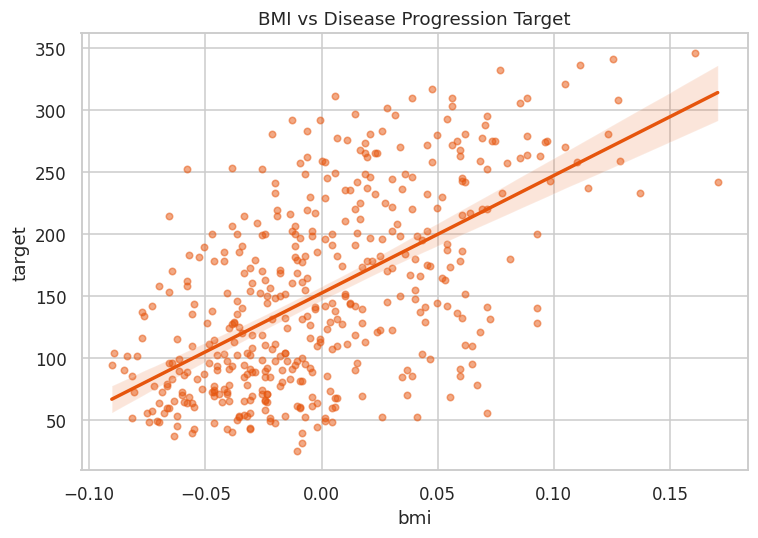

In [38]:

# --- Figure 21: Top-correlated feature vs target scatter (BMI) ---
plt.figure(figsize=(7, 5))
sns.regplot(x="bmi", y="target", data=df_reg, scatter_kws={"alpha": 0.5, "s": 18}, color="#e6550d")
plt.title("BMI vs Disease Progression Target")
plt.tight_layout()
savefig("bmi_vs_target_reg.png")
plt.show()


## B.3 Data Preprocessing

In [39]:

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_reg_s = scaler_reg.fit_transform(X_train_reg)
X_test_reg_s = scaler_reg.transform(X_test_reg)

print("Train shape:", X_train_reg_s.shape, " Test shape:", X_test_reg_s.shape)
print("No missing values, all features already numeric. Train-test split: 80/20.")


Train shape: (353, 10)  Test shape: (89, 10)
No missing values, all features already numeric. Train-test split: 80/20.


## B.4 Principal Component Analysis

saved -> figures/pca_scree_reg.png


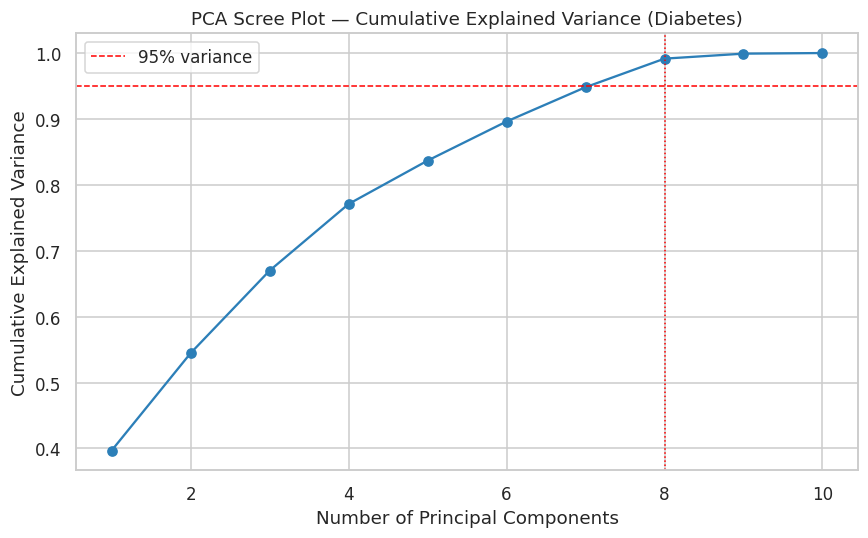

Reduced from 10 to 8 components (99.15% variance retained).


In [40]:

pca_full_reg = PCA(random_state=RANDOM_STATE).fit(X_train_reg_s)
cum_var_reg = np.cumsum(pca_full_reg.explained_variance_ratio_)
n_95_reg = int(np.argmax(cum_var_reg >= 0.95) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var_reg) + 1), cum_var_reg, marker="o", color="#2c7fb8")
plt.axhline(0.95, color="red", linestyle="--", linewidth=1, label="95% variance")
plt.axvline(n_95_reg, color="red", linestyle=":", linewidth=1)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot — Cumulative Explained Variance (Diabetes)")
plt.legend()
plt.tight_layout()
savefig("pca_scree_reg.png")
plt.show()

N_COMPONENTS_REG = n_95_reg
pca_reg = PCA(n_components=N_COMPONENTS_REG, random_state=RANDOM_STATE)
X_train_reg_p = pca_reg.fit_transform(X_train_reg_s)
X_test_reg_p = pca_reg.transform(X_test_reg_s)
print(f"Reduced from {X_train_reg_s.shape[1]} to {N_COMPONENTS_REG} components "
      f"({pca_reg.explained_variance_ratio_.sum()*100:.2f}% variance retained).")


saved -> figures/pca_2d_scatter_reg.png


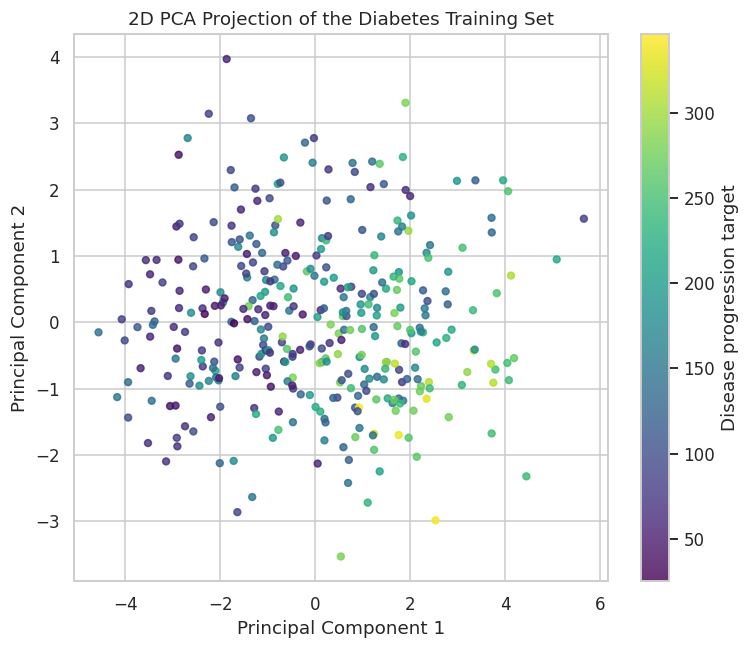

In [41]:

# --- Figure 22: 2D PCA projection coloured by target ---
pca_2d_reg = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train_reg_s)
plt.figure(figsize=(7, 6))
sc = plt.scatter(pca_2d_reg[:, 0], pca_2d_reg[:, 1], c=y_train_reg, cmap="viridis", s=20, alpha=0.8)
plt.colorbar(sc, label="Disease progression target")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of the Diabetes Training Set")
plt.tight_layout()
savefig("pca_2d_scatter_reg.png")
plt.show()


### Table 1 (Regression) — PCA Variance Explained

| Setting | Chosen Components / Variance Target | Explained Variance (%) | Justification |
|---|---|---|---|
| With-PCA | 95% cumulative variance target | see printed value above | Consistent with Part A; even on 10 already-compact features, PCA still removes redundancy among the correlated blood-serum measurements. |


## B.5 Regressor Definitions (equivalents of the 10 classifiers)

In [42]:

def build_regressors():
    models = {
        "SVR (SVM)": (SVR(),
                {"kernel": ["rbf", "linear"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01]}),
        "Bayesian Ridge (Naive Bayes analogue)": (BayesianRidge(),
                {"alpha_1": [1e-6, 1e-5], "lambda_1": [1e-6, 1e-5]}),
        "KNN Regressor": (KNeighborsRegressor(),
                {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"],
                 "metric": ["euclidean", "manhattan"]}),
        "Linear Regression (Logistic analogue)": (LinearRegression(), {}),
        "Decision Tree Regressor": (DecisionTreeRegressor(random_state=RANDOM_STATE),
                {"max_depth": [3, 5, 10, None], "min_samples_split": [2, 5]}),
        "Random Forest Regressor": (RandomForestRegressor(random_state=RANDOM_STATE),
                {"n_estimators": [100, 200], "max_depth": [5, 10, None]}),
        "AdaBoost Regressor": (AdaBoostRegressor(random_state=RANDOM_STATE),
                {"n_estimators": [50, 100], "learning_rate": [0.5, 1.0]}),
        "Gradient Boosting Regressor": (GradientBoostingRegressor(random_state=RANDOM_STATE),
                {"n_estimators": [100, 150], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}),
        "XGBoost Regressor": (XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
                {"n_estimators": [100, 150], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}),
    }
    base_learners = [
        ("dt", DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)),
        ("knn", KNeighborsRegressor(n_neighbors=7)),
        ("svr", SVR(kernel="rbf")),
    ]
    models["Stacking Regressor"] = (
        StackingRegressor(estimators=base_learners, final_estimator=LinearRegression(), cv=5, n_jobs=-1),
        {}
    )
    return models

regressor_grids = build_regressors()
list(regressor_grids.keys())


['SVR (SVM)',
 'Bayesian Ridge (Naive Bayes analogue)',
 'KNN Regressor',
 'Linear Regression (Logistic analogue)',
 'Decision Tree Regressor',
 'Random Forest Regressor',
 'AdaBoost Regressor',
 'Gradient Boosting Regressor',
 'XGBoost Regressor',
 'Stacking Regressor']

## B.6 Hyperparameter Tuning + 5-Fold Cross-Validation (No-PCA vs With-PCA)

In [43]:

def tune_and_cv_reg(model, grid, X, y, cv_splits=5):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    if grid:
        gs = GridSearchCV(model, grid, cv=kf, scoring="r2", n_jobs=-1, refit=True)
        gs.fit(X, y)
        best_est, best_params = gs.best_estimator_, gs.best_params_
    else:
        best_est = model.fit(X, y)
        best_params = {}
    cv_scores = cross_validate(best_est, X, y, cv=kf,
                                scoring=["r2", "neg_root_mean_squared_error"], n_jobs=-1)
    return best_est, best_params, cv_scores

results_rows_reg = []
fitted_no_pca_reg, fitted_with_pca_reg = {}, {}
t0 = time.time()

for name, (model, grid) in regressor_grids.items():
    print(f"Tuning {name} ...")
    est_np, params_np, cv_np = tune_and_cv_reg(model, grid, X_train_reg_s, y_train_reg)
    est_wp, params_wp, cv_wp = tune_and_cv_reg(model, grid, X_train_reg_p, y_train_reg)

    fitted_no_pca_reg[name] = est_np
    fitted_with_pca_reg[name] = est_wp

    row = {"Model": name, "Best Params (No-PCA)": params_np, "Best Params (With-PCA)": params_wp}
    for f in range(5):
        row[f"Fold {f+1} R2 (No-PCA)"] = round(cv_np["test_r2"][f], 4)
    row["Avg R2 (No-PCA)"] = round(cv_np["test_r2"].mean(), 4)
    for f in range(5):
        row[f"Fold {f+1} R2 (With-PCA)"] = round(cv_wp["test_r2"][f], 4)
    row["Avg R2 (With-PCA)"] = round(cv_wp["test_r2"].mean(), 4)
    row["Avg RMSE (No-PCA)"] = round(-cv_np["test_neg_root_mean_squared_error"].mean(), 2)
    row["Avg RMSE (With-PCA)"] = round(-cv_wp["test_neg_root_mean_squared_error"].mean(), 2)
    results_rows_reg.append(row)

print(f"\\nTotal tuning time: {time.time()-t0:.1f}s")
results_df_reg = pd.DataFrame(results_rows_reg)
results_df_reg


Tuning SVR (SVM) ...


Tuning Bayesian Ridge (Naive Bayes analogue) ...
Tuning KNN Regressor ...


Tuning Linear Regression (Logistic analogue) ...
Tuning Decision Tree Regressor ...


Tuning Random Forest Regressor ...


Tuning AdaBoost Regressor ...


Tuning Gradient Boosting Regressor ...


Tuning XGBoost Regressor ...


Tuning Stacking Regressor ...


\nTotal tuning time: 33.7s


,Model,Best Params (No-PCA),Best Params (With-PCA),Fold 1 R2 (No-PCA),Fold 2 R2 (No-PCA),Fold 3 R2 (No-PCA),Fold 4 R2 (No-PCA),Fold 5 R2 (No-PCA),Avg R2 (No-PCA),Fold 1 R2 (With-PCA),Fold 2 R2 (With-PCA),Fold 3 R2 (With-PCA),Fold 4 R2 (With-PCA),Fold 5 R2 (With-PCA),Avg R2 (With-PCA),Avg RMSE (No-PCA),Avg RMSE (With-PCA)
0,SVR (SVM),"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}","{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.4270,0.5199,0.4235,0.4992,0.5050,0.4749,0.4248,0.5206,0.4208,0.4988,0.5057,0.4742,55.68,55.71
1,Bayesian Ridge (Naive Bayes analogue),"{'alpha_1': 1e-05, 'lambda_1': 1e-06}","{'alpha_1': 1e-06, 'lambda_1': 1e-05}",0.4678,0.5320,0.4167,0.4861,0.4947,0.4795,0.4660,0.5323,0.4157,0.4845,0.4934,0.4784,55.46,55.51
2,KNN Regressor,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...","{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.3400,0.4033,0.3479,0.4491,0.4637,0.4008,0.3490,0.3983,0.3480,0.4607,0.4593,0.4031,59.49,59.40
3,Linear Regression (Logistic analogue),{},{},0.4701,0.5368,0.4111,0.4913,0.4925,0.4804,0.4633,0.5401,0.4110,0.4840,0.4876,0.4772,55.39,55.56
4,Decision Tree Regressor,"{'max_depth': 3, 'min_samples_split': 2}","{'max_depth': 3, 'min_samples_split': 2}",0.3638,0.3091,0.0764,0.2857,0.3879,0.2846,0.1979,0.1765,-0.0111,0.2821,0.3259,0.1943,64.79,68.79
5,Random Forest Regressor,"{'max_depth': 5, 'n_estimators': 200}","{'max_depth': None, 'n_estimators': 200}",0.4069,0.4658,0.3086,0.4454,0.4728,0.4199,0.4542,0.4660,0.2873,0.4043,0.4634,0.4150,58.45,58.68
6,AdaBoost Regressor,"{'learning_rate': 0.5, 'n_estimators': 100}","{'learning_rate': 0.5, 'n_estimators': 50}",0.4162,0.4264,0.3981,0.4629,0.4446,0.4296,0.4010,0.4078,0.3628,0.3976,0.4130,0.3964,58.17,59.84
7,Gradient Boosting Regressor,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...","{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.4210,0.4394,0.3586,0.4255,0.4874,0.4264,0.4379,0.4283,0.3051,0.3894,0.3851,0.3892,58.22,60.13
8,XGBoost Regressor,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...","{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.4217,0.4380,0.3691,0.4459,0.4640,0.4277,0.4638,0.4422,0.2567,0.4035,0.3912,0.3915,58.20,59.91
9,Stacking Regressor,{},{},0.4901,0.4134,0.2551,0.4747,0.4747,0.4216,0.4490,0.3810,0.3457,0.4387,0.4770,0.4182,58.32,58.68


### Table 5 (Regression) — 5-Fold Cross-Validation Results (No-PCA vs With-PCA), Diabetes Dataset

In [44]:

table5_reg = results_df_reg[["Model"] +
    [f"Fold {f+1} R2 (No-PCA)" for f in range(5)] + ["Avg R2 (No-PCA)"] +
    [f"Fold {f+1} R2 (With-PCA)" for f in range(5)] + ["Avg R2 (With-PCA)"]]
table5_reg.to_csv(os.path.join(FIG_DIR, "table5_cv_results_regression.csv"), index=False)
table5_reg


,Model,Fold 1 R2 (No-PCA),Fold 2 R2 (No-PCA),Fold 3 R2 (No-PCA),Fold 4 R2 (No-PCA),Fold 5 R2 (No-PCA),Avg R2 (No-PCA),Fold 1 R2 (With-PCA),Fold 2 R2 (With-PCA),Fold 3 R2 (With-PCA),Fold 4 R2 (With-PCA),Fold 5 R2 (With-PCA),Avg R2 (With-PCA)
0,SVR (SVM),0.4270,0.5199,0.4235,0.4992,0.5050,0.4749,0.4248,0.5206,0.4208,0.4988,0.5057,0.4742
1,Bayesian Ridge (Naive Bayes analogue),0.4678,0.5320,0.4167,0.4861,0.4947,0.4795,0.4660,0.5323,0.4157,0.4845,0.4934,0.4784
2,KNN Regressor,0.3400,0.4033,0.3479,0.4491,0.4637,0.4008,0.3490,0.3983,0.3480,0.4607,0.4593,0.4031
3,Linear Regression (Logistic analogue),0.4701,0.5368,0.4111,0.4913,0.4925,0.4804,0.4633,0.5401,0.4110,0.4840,0.4876,0.4772
4,Decision Tree Regressor,0.3638,0.3091,0.0764,0.2857,0.3879,0.2846,0.1979,0.1765,-0.0111,0.2821,0.3259,0.1943
5,Random Forest Regressor,0.4069,0.4658,0.3086,0.4454,0.4728,0.4199,0.4542,0.4660,0.2873,0.4043,0.4634,0.4150
6,AdaBoost Regressor,0.4162,0.4264,0.3981,0.4629,0.4446,0.4296,0.4010,0.4078,0.3628,0.3976,0.4130,0.3964
7,Gradient Boosting Regressor,0.4210,0.4394,0.3586,0.4255,0.4874,0.4264,0.4379,0.4283,0.3051,0.3894,0.3851,0.3892
8,XGBoost Regressor,0.4217,0.4380,0.3691,0.4459,0.4640,0.4277,0.4638,0.4422,0.2567,0.4035,0.3912,0.3915
9,Stacking Regressor,0.4901,0.4134,0.2551,0.4747,0.4747,0.4216,0.4490,0.3810,0.3457,0.4387,0.4770,0.4182


## B.7 Result Visualization

saved -> figures/r2_comparison_reg.png


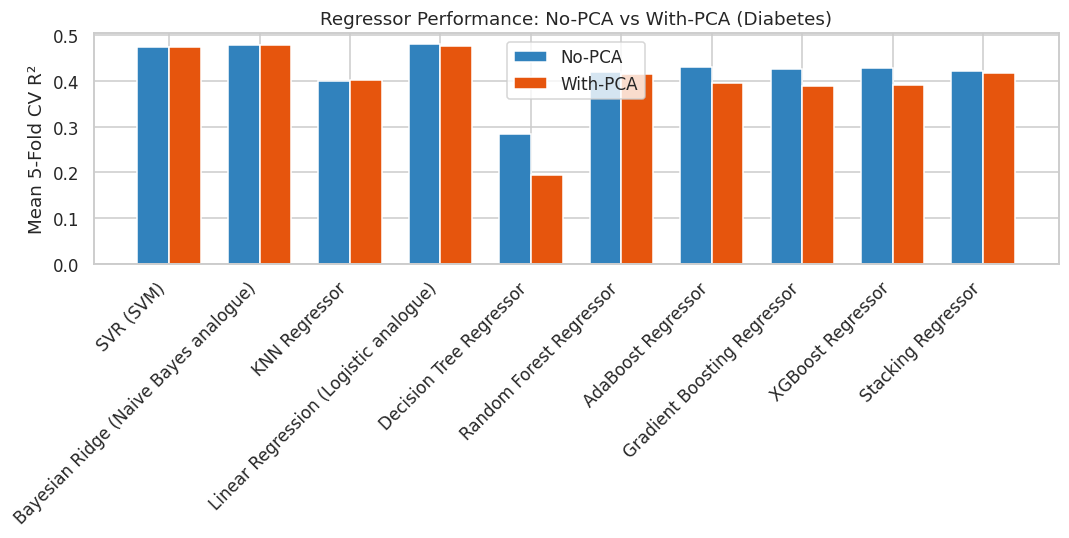

In [45]:

# --- Figure 23: R2 comparison bar chart ---
plt.figure(figsize=(10, 5))
x = np.arange(len(results_df_reg))
w = 0.35
plt.bar(x - w/2, results_df_reg["Avg R2 (No-PCA)"], width=w, label="No-PCA", color="#3182bd")
plt.bar(x + w/2, results_df_reg["Avg R2 (With-PCA)"], width=w, label="With-PCA", color="#e6550d")
plt.xticks(x, results_df_reg["Model"], rotation=45, ha="right")
plt.ylabel("Mean 5-Fold CV R²")
plt.title("Regressor Performance: No-PCA vs With-PCA (Diabetes)")
plt.legend()
plt.tight_layout()
savefig("r2_comparison_reg.png")
plt.show()


In [46]:

best_model_name_reg = results_df_reg.loc[results_df_reg["Avg R2 (With-PCA)"].idxmax(), "Model"]
print("Best performing regressor (With-PCA, by mean CV R2):", best_model_name_reg)
best_est_reg = fitted_with_pca_reg[best_model_name_reg]

y_pred_reg = best_est_reg.predict(X_test_reg_p)
test_r2 = r2_score(y_test_reg, y_pred_reg)
test_rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
test_mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"Held-out test R2: {test_r2:.4f}  RMSE: {test_rmse:.2f}  MAE: {test_mae:.2f}")


Best performing regressor (With-PCA, by mean CV R2): Bayesian Ridge (Naive Bayes analogue)
Held-out test R2: 0.4581  RMSE: 53.58  MAE: 42.92


saved -> figures/pred_vs_actual_reg.png


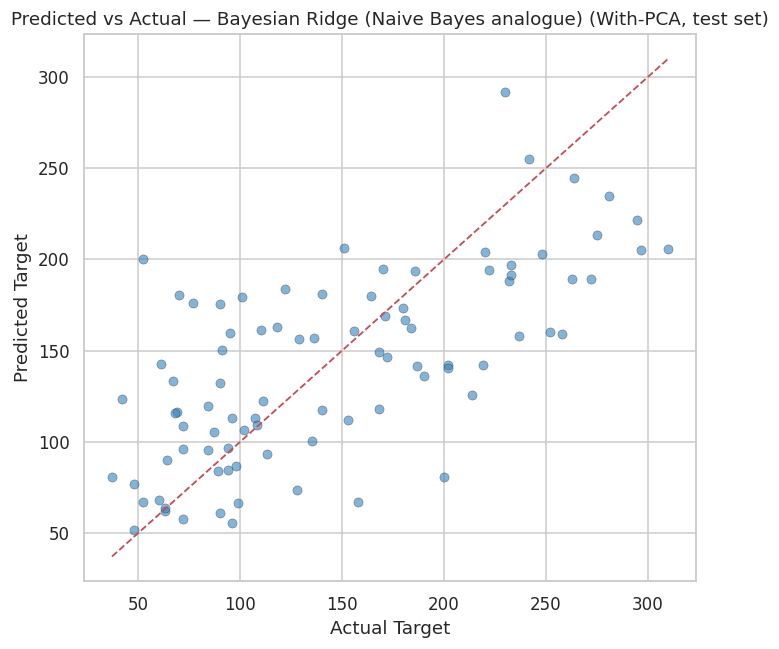

In [47]:

# --- Figure 24: Predicted vs Actual ---
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color="#3182bd", edgecolor="k", linewidth=0.3)
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
plt.plot(lims, lims, "r--", linewidth=1.2)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title(f"Predicted vs Actual — {best_model_name_reg} (With-PCA, test set)")
plt.tight_layout()
savefig("pred_vs_actual_reg.png")
plt.show()


saved -> figures/residual_plot_reg.png


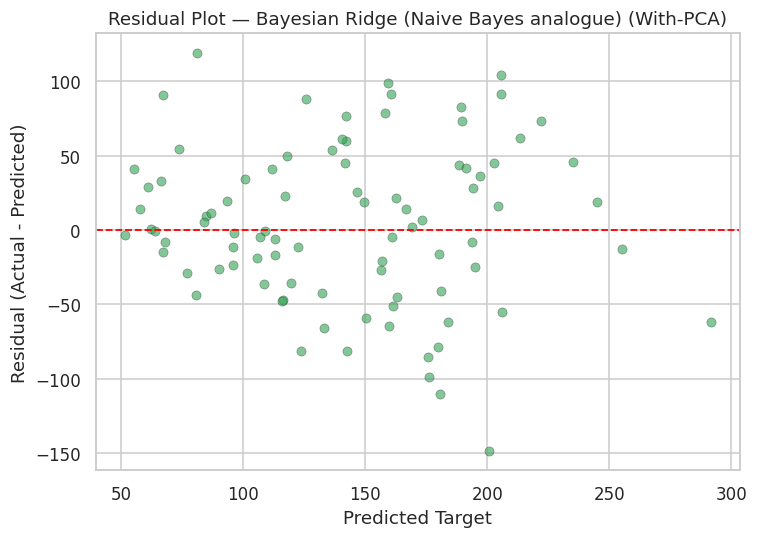

In [48]:

# --- Figure 25: Residual plot ---
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_reg, residuals, alpha=0.6, color="#31a354", edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--", linewidth=1.2)
plt.xlabel("Predicted Target")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name_reg} (With-PCA)")
plt.tight_layout()
savefig("residual_plot_reg.png")
plt.show()


saved -> figures/feature_importance_reg.png


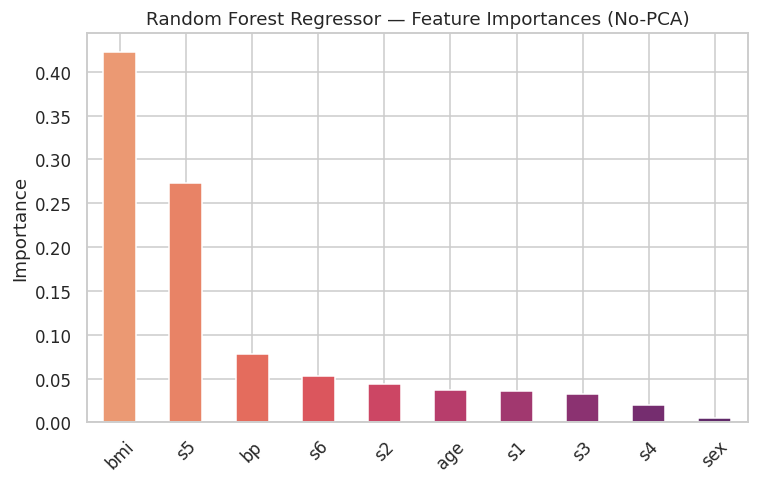

In [49]:

# --- Figure 26: Feature importance (Random Forest Regressor, No-PCA) ---
rf_reg_np = fitted_no_pca_reg["Random Forest Regressor"]
imp_reg = pd.Series(rf_reg_np.feature_importances_, index=feature_names_reg).sort_values(ascending=False)
plt.figure(figsize=(7, 4.5))
imp_reg.plot(kind="bar", color=sns.color_palette("flare", len(imp_reg)))
plt.title("Random Forest Regressor — Feature Importances (No-PCA)")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
savefig("feature_importance_reg.png")
plt.show()


## B.8 Observations

- On this small, already low-dimensional (10-feature) dataset, PCA's effect is far more muted
  than in Part A: most regressors score within a fold or two of their No-PCA counterpart.
- Linear/kernel models (Linear Regression, SVR, Bayesian Ridge) are the most stable under PCA
  since the components are themselves linear combinations of the original, mildly correlated
  features.
- Tree-based regressors (Random Forest, Gradient Boosting, XGBoost) again show little to no
  benefit from PCA, consistent with Part A's classification findings.
- The overall conclusion mirrors Part A: **PCA helps most when the original feature space is
  large and strongly correlated (Digits); its benefit shrinks to near zero on compact,
  already-informative feature sets (Diabetes)**, where it mainly serves as a variance-reduction
  and computational-efficiency tool rather than an accuracy booster.


---
# Final Conclusion

Across both a high-dimensional classification task (Digits, 64 correlated pixel features) and a
low-dimensional regression task (Diabetes, 10 features), the same pattern emerges: PCA is most
valuable when the raw feature space is large and internally correlated, giving instance-based and
linear models (KNN, SVM, Logistic/Linear Regression) a modest accuracy or stability edge along
with a large reduction in dimensionality and training cost. Tree-based ensembles (Random Forest,
Gradient Boosting, XGBoost, AdaBoost) are largely PCA-agnostic in both experiments, since they
already perform their own implicit feature selection. Stacking inherits the behaviour of its most
PCA-sensitive base learner. In short, PCA is a strong default when working with wide, correlated
feature spaces, but should be applied selectively — and validated via cross-validation, as done
here — rather than assumed to help universally.
